## **Assignment Two (EECS3405 F25)**

**your name (your student number):**. Karen Lau (--)

**your yorku email:**. --

This assignment is mainly for you to review linear methods or simple discriminative models. You have to work individually. Remember to fill in your information (name, student number, email) at above.


##**What to Submit**

Please use this notebook to complete this assignment. You have to run your codes and show the results in this notebook. Download the completed notenook as `.ipynb` and compress it as a `.zip` file to submit to eClass.  Submit only ONE notebook file that contains all of your answers and codes to eClass before the deadline.  No late submission
will be accepted.

* For all written parts, write your answers in text cells. To avoid confusions in marking, better to embed latex codes there to represent all mathematical notations and equations.  **No handwriting is accepted**.

* For programming parts, you should give codes, comments, explanations and the proper running outputs in both code and text cells. Make your jupyter notebook clean and concise. Remove all unused codes and all intermediate results from the submitted notebook. The submitted notebook should include only the final (best) outputs for each question. Also make sure every code cell runnable so that markers can reproduce the outputs if necessary.

### **Q1** (20 marks) **Linear Discriminant Analysis (LDA)**


**Part 1.1** (10 marks) Use the method of Lagrange multipliers to derive the solution to LDA on the lecture notes.


**write your answer to Q1.1 here:**

From the slides we are given:
$$ \hat{w} = \arg\max_{w} \frac{w^{⊤} S_b w}{w^{\top} S_w w}
$$

To optimize this, we will use the method of Lagrange multipliers to evalulate the following equivalent expression (also given in slides):
$$ {w^*} = \arg\max_{w} w^{⊤} S_b w $$
subject to $${w^{\top} S_w w} = 1$$

Below we will derive the solution:

$$L(w, \lambda) = w^{⊤} S_b w - \lambda(w^{⊤} S_w w - 1)$$

$$
\begin{aligned}
\frac{\partial L(w, \lambda)}{\partial \mathbf{w}}
          &=  2S_bw - 2 \lambda S_ww = 0\\
         S_bw &= \lambda S_ww \\
            ((S_w)^{-1}S_b)w &= \lambda w
\end{aligned}
$$

This implies that the Fisher ratio is maximized when the projection direction, $w$, is an eigenvector of the matrix $(S_w)^{-1}S_b$.

**Part 1.2** (10 marks) Following [the given PCA examples](https://colab.research.google.com/drive/1_0pfK2QOtoL1OeaFzNRiCN7SqKNAOQGG),
use all training images of four digits ('1', '3', '6', and '9') in MNIST to estimate LDA projection matrices for all possible LDA dimensions. What are the maximum LDA dimensions you can use in this case?
What if you only use all training images of three digits ('3', '6', and '9')?
Use LDA to project all images into 2D and/or 3D space, and compare its visualization with those of PCA and t-SNE.

In [ ]:
# write your codes for Q1.2 here

In [ ]:
# download MNIST data

!gdown --folder https://drive.google.com/drive/folders/1r20aRjc2iu9O3kN3Xj9jNYY2uMgcERY1 2> /dev/null

#install python_mnist

!pip install python_mnist

Processing file 1Jf2XqGR7y1fzOZNKLJiom7GmZZUzXhfs t10k-images-idx3-ubyte
Processing file 1qiYu9dW3ZNrlvTFO5fI4qf8Wtr8K-pCu t10k-labels-idx1-ubyte
Processing file 1SnWvBcUETRJ53rEJozFUUo-hOQFPKxjp train-images-idx3-ubyte
Processing file 1kKEIi_pwVHmabByAnwZQsaMgro9XiBFE train-labels-idx1-ubyte


In [ ]:
#load MINST images

from mnist import MNIST
import numpy as np

mnist_loader = MNIST('MNIST')
train_data, train_label = mnist_loader.load_training()
test_data, test_label = mnist_loader.load_testing()
train_data = np.array(train_data, dtype='float')/255 # norm to [0,1]
train_label = np.array(train_label, dtype='short')
test_data = np.array(test_data, dtype='float')/255 # norm to [0,1]
test_label = np.array(test_label, dtype='short')

#add small random noise to avoid matrix singularity
train_data += np.random.normal(0,0.0001,train_data.shape)
print(train_data.shape, train_label.shape, test_data.shape, test_label.shape)

(60000, 784) (60000,) (10000, 784) (10000,)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# load images of '1', '3', '6', '9'
selected_digits = [1, 3, 6, 9]
digit_index = np.isin(train_label, selected_digits)
X = train_data[digit_index]
y = train_label[digit_index]
print(X.shape, y.shape)

# load images of '3', '6', '9'
selected_digits2 = [3, 6, 9]
digit_index2 = np.isin(train_label, selected_digits2)
X2 = train_data[digit_index2]
y2 = train_label[digit_index2]
print(X2.shape, y2.shape)

(24740, 784) (24740,)
(17998, 784) (17998,)


In Q1a, we found that LDA projections correspond to the eigenvectors of the matrix $(S_w)^{-1}S_b$. This is not a full rank matrix, and thus we know that LDA has at most $k-1$ projection directions, where $k$ is the number of groups.
- For the subset using training images of four digits - 1, 3, 6, 9 - this implies the maximum number of projection directions is 3 (4-1).
- Similarly, for the subset using training images of three digits - 3, 6, 9 -  this implies the maximum number of projection directions is 2 (3-1).

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

#Subset 1 - 4 classes: 1, 3, 6, 9

#LDA 2-dimension plotting
lda2 = LDA(n_components=2)
Y_lda2 = lda2.fit_transform(X, y)

#LDA 3-dimension plotting
lda3 = LDA(n_components=3)
Y_lda3 = lda3.fit_transform(X, y)

#PCA 2-dimension plotting
pca2 = PCA(n_components=2)
Y_pca2 = pca2.fit_transform(X)

#PCA 3-dimension plotting
pca3 = PCA(n_components=3)
Y_pca3 = pca3.fit_transform(X)

In [ ]:
#t-SNE 2-dimension plotting
tsne2 = TSNE(n_components=2, perplexity=20)
Y_tsne2 = tsne2.fit_transform(X)

In [ ]:
#t-SNE 3-dimension plotting
tsne3 = TSNE(n_components=3, perplexity=20)
Y_tsne3 = tsne3.fit_transform(X)

In [ ]:
#Creating functions to simplify plotting code - repetitive
#Ensures consistency between plots
def plot_2d(Y, y, title):
    plt.figure()
    plt.scatter(Y[y == 1, 0], Y[y == 1, 1], marker='o', color='#2A7F62')
    plt.scatter(Y[y == 3, 0], Y[y == 3, 1], marker='^', color='#ff7f0e')
    plt.scatter(Y[y == 6, 0], Y[y == 6, 1], marker='d', color='#6D597A')
    plt.scatter(Y[y == 9, 0], Y[y == 9, 1], marker='s', color='#9E1946')
    plt.legend(['1', '3', '6', '9'])
    plt.title(title)
    plt.show()

def plot_3d(Y, y, title):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(xs=Y[y == 1, 0], ys=Y[y == 1, 1], zs=Y[y == 1, 2], marker='o', color='#2A7F62')
    ax.scatter(xs=Y[y == 3, 0], ys=Y[y == 3, 1], zs=Y[y == 3, 2], marker='^', color='#ff7f0e')
    ax.scatter(xs=Y[y == 6, 0], ys=Y[y == 6, 1], zs=Y[y == 6, 2], marker='d', color='#6D597A')
    ax.scatter(xs=Y[y == 9, 0], ys=Y[y == 9, 1], zs=Y[y == 9, 2], marker='s', color='#9E1946')
    ax.legend(['1', '3', '6', '9'])
    ax.set_title(title)
    plt.show()

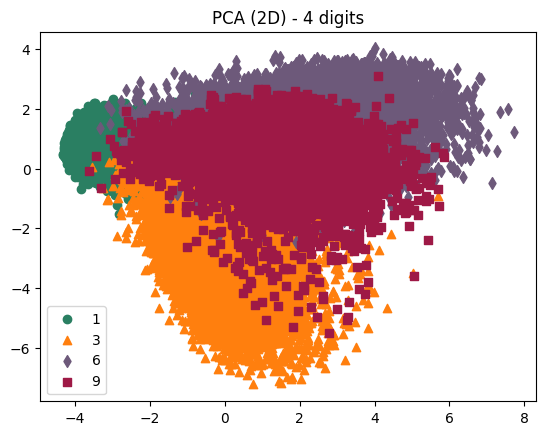

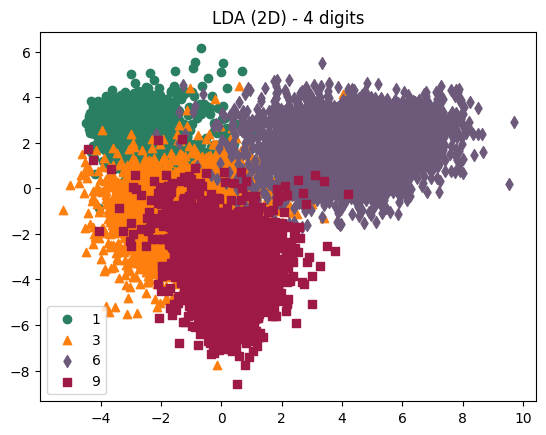

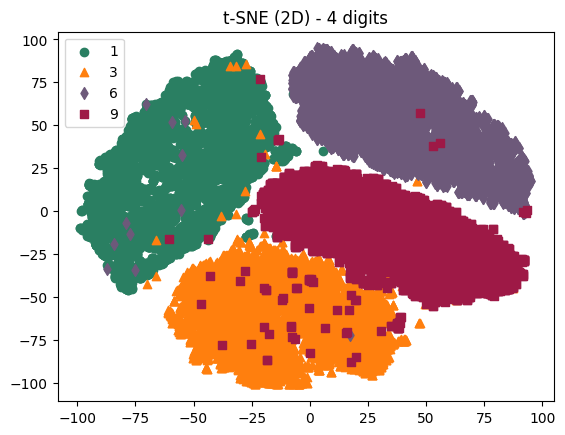

In [ ]:
# Plot 2-dimension visualizations
plot_2d(Y_pca2, y, 'PCA (2D) - 4 digits')
plot_2d(Y_lda2, y, 'LDA (2D) - 4 digits')
plot_2d(Y_tsne2, y, 't-SNE (2D) - 4 digits')

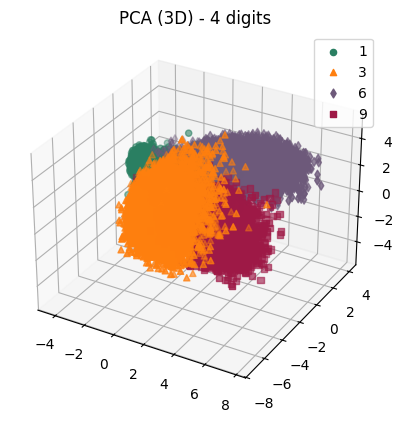

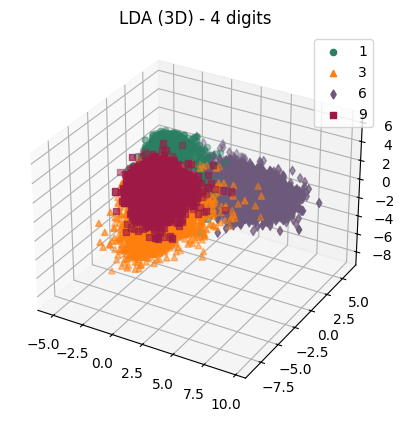

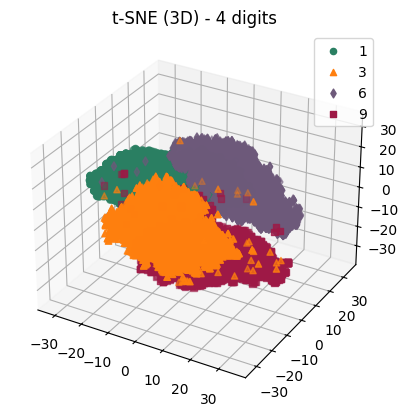

In [ ]:
# Plot 3-dimension visualizations
plot_3d(Y_pca3, y, 'PCA (3D) - 4 digits')
plot_3d(Y_lda3, y, 'LDA (3D) - 4 digits')
plot_3d(Y_tsne3, y, 't-SNE (3D) - 4 digits')

In [ ]:
#Subset 2 - 3 classes: 3, 6, 9
#As explained previously, can only do 2D plotting

#LDA
lda2_3digits = LDA(n_components=2)
Y_lda2_3digits = lda2_3digits.fit_transform(X2, y2)

#PCA
pca2_3digits = PCA(n_components=2)
Y_pca2_3digits = pca2_3digits.fit_transform(X2)

In [ ]:
#3-digit subset
#t-SNE
tsne2_3digits = TSNE(n_components=2, perplexity=20)
Y_tsne2_3digits = tsne2_3digits.fit_transform(X2)

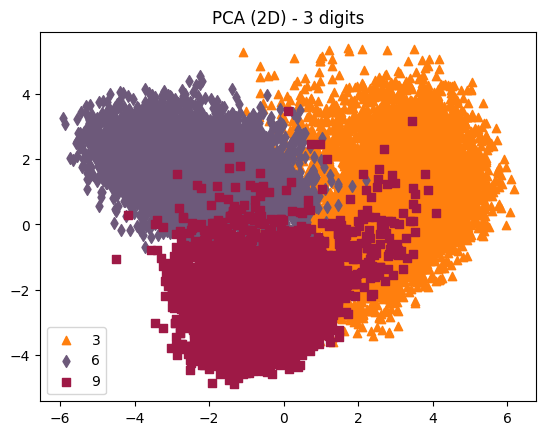

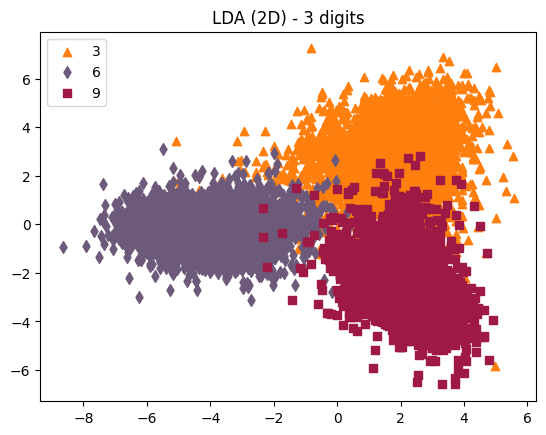

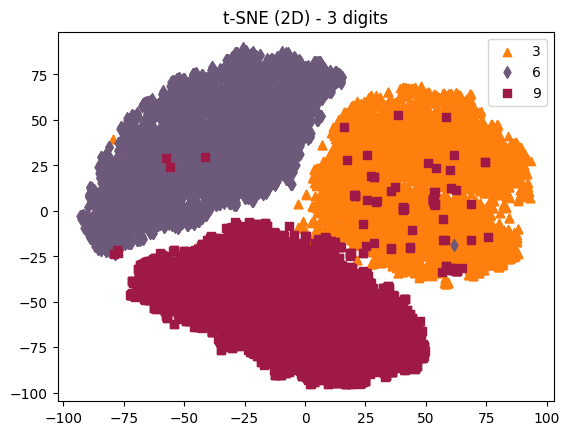

In [ ]:
#Creating functions to simplify plotting code - repetitive
#Ensures consistency between plots
def plot_2d3(Y, y, title):
    plt.figure()
    plt.scatter(Y[y == 3, 0], Y[y == 3, 1], marker='^', color='#ff7f0e')
    plt.scatter(Y[y == 6, 0], Y[y == 6, 1], marker='d', color='#6D597A')
    plt.scatter(Y[y == 9, 0], Y[y == 9, 1], marker='s', color='#9E1946')
    plt.legend(['3', '6', '9'])
    plt.title(title)
    plt.show()

plot_2d3(Y_pca2_3digits, y2, 'PCA (2D) - 3 digits')
plot_2d3(Y_lda2_3digits, y2, 'LDA (2D) - 3 digits')
plot_2d3(Y_tsne2_3digits, y2, 't-SNE (2D) - 3 digits')

**Overall Conclusions:**
From the 2-dimension and 3-dimension plots created above we can derive the following conclusions (subset 1 - 4 digits classes):
- PCA does poorly while separating the classes. There is plenty of overlap between digit classes. This is especially evident in the 3-dimensional plot as there are no distinct coloured clusters. This makes sense as the algorithm prioritizes maximizing variance and ignores class labels altogether.
- LDA does a moderate job at separating the digit classes. We can see clearer class distinctions (compared to the PCA algorithm). However, there is still some overlap between the classes/clusters. This is especially evident in the 3-dimensional plot as you can clearly see each digit cluster, but there are areas where the clusters intersect.
- t-SNE is the best model to distinguish between digit classes. We can see clear class separations in both 2-D and 3-D plots.

The same conclusions can be derived from subset 2 (with three-digit classes).

### **Q2** (10 marks)  **MCE vs. Logistic Regression**

Revise the given [logistic regression implementation](https://colab.research.google.com/drive/1f5w-RQZIYdL4nlog9QAoSoa62Nivv_8H) to implement minimum classification error (MCE) method to learn a binary classifier to classify two digits ('7' vs. '9') in the MNIST data set. Compare its performance with that of logistic regression and report the best results in the heldout test data of these two digits.

In [ ]:
# write your codes for Q2 here

In [ ]:
#load MINST images

from mnist import MNIST
import numpy as np

mnist_loader = MNIST('MNIST')
train_data, train_label = mnist_loader.load_training()
test_data, test_label = mnist_loader.load_testing()
train_data = np.array(train_data, dtype='float')/255 # norm to [0,1]
train_label = np.array(train_label, dtype='short')
test_data = np.array(test_data, dtype='float')/255 # norm to [0,1]
test_label = np.array(test_label, dtype='short')

#add small random noise to avoid matrix singularity
train_data += np.random.normal(0,0.0001,train_data.shape)
print(train_data.shape, train_label.shape, test_data.shape, test_label.shape)

(60000, 784) (60000,) (10000, 784) (10000,)


In [ ]:
# prepare digits '7' and '9' for logistic regression

digit_train_index = np.logical_or(train_label == 7, train_label == 9)
X_train = train_data[digit_train_index]
y_train = train_label[digit_train_index]
digit_test_index = np.logical_or(test_label == 7, test_label == 9)
X_test = test_data[digit_test_index]
y_test = test_label[digit_test_index]

# add a constant column of '1' to accomodate the bias (see the margin note on page 107)
X_train = np.hstack((X_train, np.ones((X_train.shape[0], 1), dtype=X_train.dtype)))
X_test = np.hstack((X_test, np.ones((X_test.shape[0], 1), dtype=X_test.dtype)))

# converge labels: '3' => -1, '8' => +1
CUTOFF = 8 # any number between '7' and '9'
y_train = np.sign(y_train-CUTOFF)
y_test = np.sign(y_test-CUTOFF)

Section 6.3 of the textbook discusses the MCE method. It mentions that the MCE method is the learning algorithm which minimizes the following objective function (eq. 6.13):
$$
E_1(\mathbf{w})= \sum^{N}_{i=1}l(-y_i\mathbf{w}^{⊤}\mathbf{x}_i)
$$

where $l(-y_i\mathbf{w}^{⊤}\mathbf{x}_i)$ is a quantity between 0 and 1.

The gradient of the above objective function is computed as the following (eq. 6.14):

$$
\frac{\partial{E_1(\mathbf{w})}}{\partial{\mathbf{w}}} = \sum^{N}_{i=1}y_il(y_i\mathbf{w}^{\top}\mathbf{x}_i)\left(1-l(y_i\mathbf{w}^{\top}\mathbf{x}_i)\right)\mathbf{x}_i
$$

If the average loss per sample is considered as the following function:
$$
E_1(\mathbf{w})= \frac{1}{N}\sum^{N}_{i=1}l(-y_i\mathbf{w}^{⊤}\mathbf{x}_i)
$$
Then the loss function is:
$$
l(-y_i\mathbf{w}^{⊤}\mathbf{x}_i)
$$

Below, we will implement these findings and changes into the given logistic regression implementation to change it into an MCE implementation.

In [ ]:
# GIVEN logistic regression using mini-batch gradient descent (from lab3) - changing to MCE method
import numpy as np

class Optimizer():
  def __init__(self, lr, annealing_rate, batch_size, max_epochs):
    self.lr = lr
    self.annealing_rate = annealing_rate
    self.batch_size = batch_size
    self.max_epochs = max_epochs

# sigmoid for numpy arrays
def sigmoid(x):
  return 1/(1 + np.exp(-x))

# X[N,d]: training features; y[N]: training targets;
# X2[N,d]: test features; y2[N]: test targets;
# op: hyper-parameters for optimzer
#
# Note: X2 and y2 are not used in training
#       but only for computing the learning curve B
#
def mce_gd(X, y, X2, y2, op):
  n = X.shape[0]            # number of samples
  w = np.zeros(X.shape[1])  # initialization

  lr = op.lr
  errorsA = np.zeros(op.max_epochs)
  errorsB = np.zeros(op.max_epochs)
  errorsC = np.zeros(op.max_epochs)

  for epoch in range(op.max_epochs):
    indices = np.random.permutation(n)  #randomly shuffle data indices
    for batch_start in range(0, n, op.batch_size):
      X_batch = X[indices[batch_start:batch_start + op.batch_size]]
      y_batch = y[indices[batch_start:batch_start + op.batch_size]]

      # vectorization to compute gradients for a whole mini-batch (see the above formula)
      ##CHANGE THIS LINE OF CODE TO MATCH THE GRADIENT WE DERIVED FOR MCE
      sig = sigmoid(y_batch * (X_batch @ w))
      w_grad = -(X_batch.T @ ((y_batch * sig)*(1-sig)))/ X_batch.shape[0] #include negative for gradient DESCENT

      w -= lr * w_grad

    # for learning curve C
    errorsC[epoch]  = np.mean(sigmoid(-y * (X @ w)))  # CHANGE TO MCE LOSS FUNCTION

    # for learning curve A
    predict = np.sign(X @ w)
    errorsA[epoch] = np.count_nonzero(np.equal(predict,y))/y.size

    # for learning curve B
    predict2 = np.sign(X2 @ w)
    errorsB[epoch] = np.count_nonzero(np.equal(predict2,y2))/y2.size

    lr *= op.annealing_rate

  print(f'epoch={epoch}: MCE loss is C={errorsC[epoch]:.3f} (A={errorsA[epoch]:.3f},B={errorsB[epoch]:.3f})')
  return w, errorsA, errorsB, errorsC

In [ ]:
# GIVEN logistic regression using mini-batch gradient descent
import numpy as np

class Optimizer():
  def __init__(self, lr, annealing_rate, batch_size, max_epochs):
    self.lr = lr
    self.annealing_rate = annealing_rate
    self.batch_size = batch_size
    self.max_epochs = max_epochs

# sigmoid for numpy arrays
def sigmoid(x):
  return 1/(1 + np.exp(-x))

# X[N,d]: training features; y[N]: training targets;
# X2[N,d]: test features; y2[N]: test targets;
# op: hyper-parameters for optimzer
#
# Note: X2 and y2 are not used in training
#       but only for computting the learning curve B
#
def logistic_regression_gd(X, y, X2, y2, op):
  n = X.shape[0]            # number of samples
  w = np.zeros(X.shape[1])  # initialization

  lr = op.lr
  errorsA = np.zeros(op.max_epochs)
  errorsB = np.zeros(op.max_epochs)
  errorsC = np.zeros(op.max_epochs)

  for epoch in range(op.max_epochs):
    indices = np.random.permutation(n)  #randomly shuffle data indices
    for batch_start in range(0, n, op.batch_size):
      X_batch = X[indices[batch_start:batch_start + op.batch_size]]
      y_batch = y[indices[batch_start:batch_start + op.batch_size]]

      # vectorization to compute gradients for a whole mini-batch (see the above formula)
      w_grad = X_batch.T @ (y_batch * sigmoid(y_batch * (X_batch @ w)) - y_batch) / X_batch.shape[0]

      w -= lr * w_grad

    # for learning curve C
    errorsC[epoch]  = - np.mean(np.log( sigmoid(y * (X @ w))) )  # logisic regression loss function
                                                                 # see the above formula
    # for learning curve A
    predict = np.sign(X @ w)
    errorsA[epoch] = np.count_nonzero(np.equal(predict,y))/y.size

    # for learning curve B
    predict2 = np.sign(X2 @ w)
    errorsB[epoch] = np.count_nonzero(np.equal(predict2,y2))/y2.size

    lr *= op.annealing_rate

  print(f'epoch={epoch}: the logistic regression loss is C={errorsC[epoch]:.3f} (A={errorsA[epoch]:.3f},B={errorsB[epoch]:.3f})')
  return w, errorsA, errorsB, errorsC

In [ ]:
#Train the models
op = Optimizer(lr=0.1, annealing_rate=0.99, batch_size=64, max_epochs=30)

w_log, A_log, B_log, C_log = logistic_regression_gd(X_train, y_train, X_test, y_test, op)
w_mce, A_mce, B_mce, C_mce = mce_gd(X_train, y_train, X_test, y_test, op)


epoch=29: the logistic regression loss is C=0.111 (A=0.962,B=0.964)
epoch=29: MCE loss is C=0.054 (A=0.957,B=0.963)


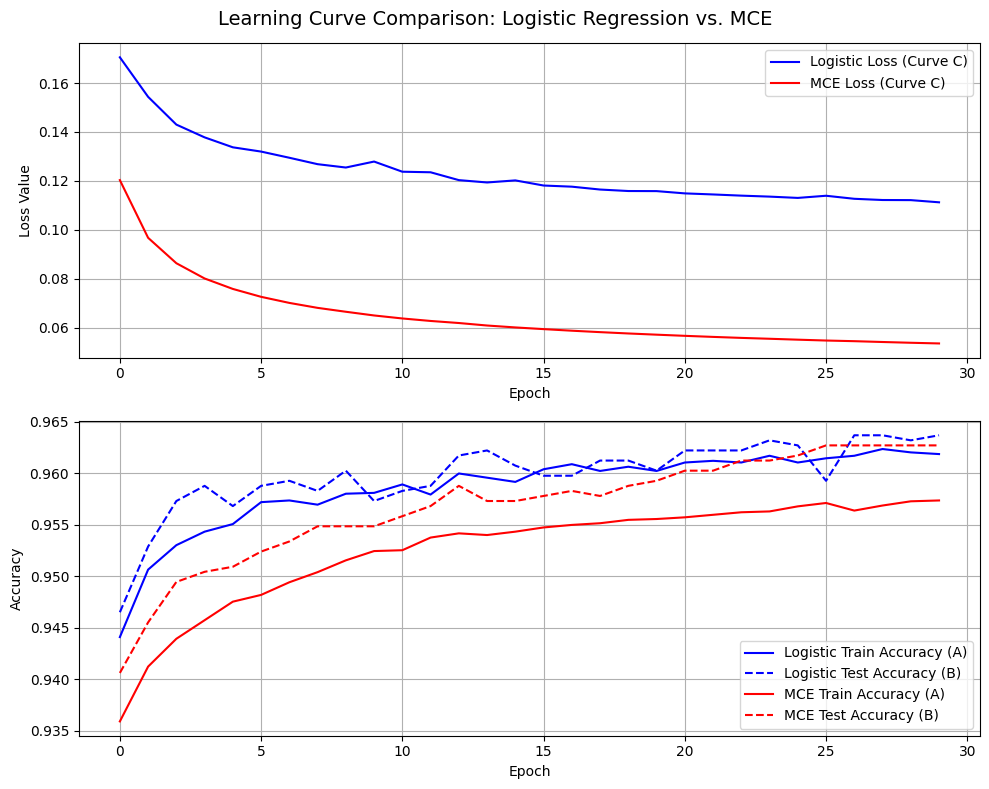

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle('Learning Curve Comparison: Logistic Regression vs. MCE', fontsize=14)

# ---- Curve C: Objective (Loss) ----
ax[0].plot(C_log, 'b', label='Logistic Loss (Curve C)')
ax[0].plot(C_mce, 'r', label='MCE Loss (Curve C)')
ax[0].set_ylabel('Loss Value')
ax[0].set_xlabel('Epoch')
ax[0].legend()
ax[0].grid(True)


# ---- Curves A and B: Train/Test Accuracy ----
ax[1].plot(A_log, 'b', label='Logistic Train Accuracy (A)')
ax[1].plot(B_log, 'b--', label='Logistic Test Accuracy (B)')
ax[1].plot(A_mce, 'r', label='MCE Train Accuracy (A)')
ax[1].plot(B_mce, 'r--', label='MCE Test Accuracy (B)')
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

Above, we have implemented a logistic regression and an MCE model. Strictly looking at their performance on held out data (test accuracy), we can observe that both models had an equal performance of 96.3%. This implies that both models' generalization performance (to unseen data) is equivalent, despite their differences in their training performance.

### **Q3** (20 marks)  **Support Vector Machine (SVM)**

**Part 3.1** (10 marks): Use the training data of two digits ('7' and '9') to learn two binary SVM classifiers (one linear SVM and one nonlinear SVM with Gaussian RBF kernel), fine-tuning all hyperparameters (such as $C$ and/or $\gamma$) for the best possible results. Report your  best classification performance in the held-out test data. Compare the `scikit-learn` implementation and [the given PGD optimizer](https://colab.research.google.com/drive/1x0sLi1SNaWK_O-LOeIGoUXdMfjjkj8bY) in terms of classification accuracy and running speed.

In [ ]:
# write your code for Q3.1 here

In [ ]:
#load MINST images

from mnist import MNIST
import numpy as np

mnist_loader = MNIST('MNIST')
train_data, train_label = mnist_loader.load_training()
test_data, test_label = mnist_loader.load_testing()
train_data = np.array(train_data, dtype='float')/255 # norm to [0,1]
train_label = np.array(train_label, dtype='short')
test_data = np.array(test_data, dtype='float')/255 # norm to [0,1]
test_label = np.array(test_label, dtype='short')

#add small random noise to avoid matrix singularity
train_data += np.random.normal(0,0.0001,train_data.shape)
print(train_data.shape, train_label.shape, test_data.shape, test_label.shape)

(60000, 784) (60000,) (10000, 784) (10000,)


In [ ]:
# prepare digits '7' and '9' for binary SVMs

digit_train_index = np.logical_or(train_label == 7, train_label == 9)
X_train = train_data[digit_train_index]
y_train = train_label[digit_train_index]
digit_test_index = np.logical_or(test_label == 7, test_label == 9)
X_test = test_data[digit_test_index]
y_test = test_label[digit_test_index]

# normalize all feature vectors to unit-length
X_train = np.transpose (X_train.T / np.sqrt(np.sum(X_train*X_train, axis=1)))
X_test =  np.transpose (X_test.T  / np.sqrt(np.sum(X_test*X_test, axis=1)))

# convert labels: '7' => -1, '9' => +1
CUTOFF = 8 # a number between '7' and '9'
y_train = np.sign(y_train-CUTOFF)
y_test = np.sign(y_test-CUTOFF)

In [ ]:
# linear SVM: use sk-learn SVC functions
import numpy as np
from sklearn.svm import SVC

for c in [0.01, 0.1, 1, 2, 4, 10]:
  linearSVM = SVC(kernel='linear', C=c)
  linearSVM.fit(X_train,y_train)
  predict = linearSVM.predict(X_train)
  train_acc = np.count_nonzero(np.equal(predict,y_train))/y_train.size
  predict = linearSVM.predict(X_test)
  test_acc = np.count_nonzero(np.equal(predict,y_test))/y_test.size
  print(f'linear SVM (C={c}): training accuracy={100*train_acc:.2f}%  test accuracy={100*test_acc:.2f}%')


linear SVM (C=0.01): training accuracy=93.95%  test accuracy=94.65%
linear SVM (C=0.1): training accuracy=95.60%  test accuracy=96.12%
linear SVM (C=1): training accuracy=96.39%  test accuracy=96.51%
linear SVM (C=2): training accuracy=96.72%  test accuracy=96.71%
linear SVM (C=4): training accuracy=96.95%  test accuracy=96.86%
linear SVM (C=10): training accuracy=97.06%  test accuracy=97.01%


From the above code and output, we find that the best classification performance on held out data (test accuracy) was 97.01%. This occurred when the hyperparameter, $C$, is set to 10.
I claim that this is the best for our linear SVM, since we can see that there is not much increase in test accuracy between $C=4$ and $C=10$.

Additionally, we do not want to keep increasing $C$, just to obtain a 100.00% test accuracy as this would suggest we are overfitting the model. Our current model with $C=10$, does not seem to be overfitting as the training and test accuracies are similar.

In [ ]:
# nonlinear SVM (Gaussian RBF kernel): use sk-learn SVC functions
import numpy as np
from sklearn.svm import SVC

for c in [1, 2, 10]:
  for g in ['scale', 1, 2]:
    rbfSVM = SVC(kernel='rbf', C=c, gamma=g)
    rbfSVM.fit(X_train,y_train)
    predict = rbfSVM.predict(X_train)
    train_acc = np.count_nonzero(np.equal(predict,y_train))/y_train.size
    predict = rbfSVM.predict(X_test)
    test_acc = np.count_nonzero(np.equal(predict,y_test))/y_test.size
    print(f'nonlinear RBF SVM (C={c},gamma={g}): training accuracy={100*train_acc:.2f}%  test accuracy={100*test_acc:.2f}%')

nonlinear RBF SVM (C=1,gamma=scale): training accuracy=99.62%  test accuracy=98.82%
nonlinear RBF SVM (C=1,gamma=1): training accuracy=99.53%  test accuracy=98.77%
nonlinear RBF SVM (C=1,gamma=2): training accuracy=99.81%  test accuracy=99.31%
nonlinear RBF SVM (C=2,gamma=scale): training accuracy=99.80%  test accuracy=99.12%
nonlinear RBF SVM (C=2,gamma=1): training accuracy=99.78%  test accuracy=98.97%
nonlinear RBF SVM (C=2,gamma=2): training accuracy=99.94%  test accuracy=99.41%
nonlinear RBF SVM (C=10,gamma=scale): training accuracy=100.00%  test accuracy=99.36%
nonlinear RBF SVM (C=10,gamma=1): training accuracy=99.99%  test accuracy=99.31%
nonlinear RBF SVM (C=10,gamma=2): training accuracy=100.00%  test accuracy=99.46%


From the above code and output, we find that the best classification performance on held out data (test accuracy) was 99.46%. This occurred when the hyperparameters are: $C=10$ and $\gamma =2$.

I claim that these are the best hyperparameters for our non-linear (Gaussian RBF kernel) SVM, since they exhibit the highest test accuracy. Additionally, there is no suggestion of overfitting since the training and test accuracies are similar.

Between the two SVM models we derived above, the linear SVM model had a test accuracy of 97.01%. In contrast, the non-linear Gaussian RBF model had a test accuracy of 99.46%.

This suggests that the non-linear Gaussian RBF model is a better classifier for this task.

In [ ]:
#GIVEN PGD Optimizer
# solve linear SVMs using projected gradient descent (PGD)
import numpy as np

class mySVM1():
  def __init__(self, kernel='linear', optimizer='pgd', debug=0, threshold=0.001, \
               lr=1.0, max_epochs=10, batch_size=2, C=1):
    self.kernel = kernel        # kernel type
    self.optimizer = optimizer  # which optimizer is used to solve quadratic programming
    self.lr = lr                # max learning rate in PGD
    self.max_epochs = max_epochs   # max epochs in PGD
    self.batch_size = batch_size   # size of each subset in PGD
    self.debug = debug             # whether print debugging info
    self.threshold = threshold     # threshold to filter out support vectors

    self.C = C     # C for the soft-margin term

  # Linear Kernel Function
  # X[N,d]: training samples;  Y[M,d]: other training samples
  # return Q[N,N]: linear kernel matrix between X and Y
  def Kernel(self, X, Y):
    if (self.kernel == 'linear'):
      K = X @ Y.T

    return K

  # construct matrix Q from any kernel function for dual SVM optimization
  def QuadraticMatrix(self, X, y):
    Q = np.outer(y, y) * self.Kernel(X, X)
    return Q

  # use projected gradient descent to solve quadratic program
  # refer to Algorithm 6.5 on page 127
  # Q[N,N]: quadratic matrix;  y[N]: training labels (+1 or -1)
  def PGD(self, Q, y):
    N = Q.shape[0]   # num of training samples
    alpha = np.zeros(N)
    prev_L = 0.0

    for epoch in range(self.max_epochs):
      indices = np.random.permutation(N)  #randomly shuffle data indices
      for batch_start in range(0, N, self.batch_size):
        idx = indices[batch_start:batch_start + self.batch_size] # indices of the selected subset
        alpha_s = alpha[idx]
        y_s = y[idx]

        grad_s = Q[idx,:] @ alpha - np.ones(idx.shape[0])
        proj_grad_s = grad_s - np.dot(y_s,grad_s)/np.dot(y_s, y_s)*y_s

        bound = np.zeros(idx.shape[0])
        bound[proj_grad_s < 0] = self.C

        eta = np.min(np.abs(alpha_s-bound)/(np.abs(proj_grad_s)+0.001))

        alpha[idx] -= min(eta, self.lr) * proj_grad_s

      L = 0.5 * alpha.T @ Q @ alpha - np.sum(alpha) # objectibve function
      if (L > prev_L):
        if (self.debug>0):
          print('Early stopping at epoch={epoch}!')
        break

      if (self.debug>1):
        print(f'[PGD optimizer] epoch = {epoch}: L = {L:.5f}  (# of support vectors = {(alpha>self.threshold).sum()})')
        print(f'                 alpha: max={np.max(alpha)} min={np.min(alpha)} orthogonal constraint={np.dot(alpha,y):.2f}')

      prev_L = L

    return alpha

  # train SVM from training samples
  # X[N,d]: input features;  y[N]: output labels (+1 or -1)
  def fit(self, X, y):
    if(self.kernel != 'linear'):
      print("Error: only linear kernel is supported!")
      return

    Q = self.QuadraticMatrix(X, y)

    alpha = self.PGD(Q, y)

    #save support vectors (pruning all data with alpha==0)
    self.X_SVs = X[alpha>self.threshold]
    self.y_SVs = y[alpha>self.threshold]
    self.alpha_SVs = alpha[alpha>self.threshold]

    # compute weight vector for linear SVMs (refer to the formula on page 120)
    if(self.kernel == 'linear'):
      self.w = (self.y_SVs * self.alpha_SVs) @ self.X_SVs

    # estimate b
    idx = np.nonzero(np.logical_and(self.alpha_SVs>self.threshold,self.alpha_SVs<self.C-self.threshold))
    if(len(idx) == 0):
      idx = np.nonzero(self.alpha_SVs>self.threshold)
    # refer to the formula on page 125 (above Figure 6.11)
    b = self.y_SVs[idx] - (self.y_SVs * self.alpha_SVs) @ self.Kernel(self.X_SVs, self.X_SVs[idx])
    self.b = np.median(b)

    return

  # use SVM from prediction
  # X[N,d]: input features
  def predict(self, X):
    if(self.kernel != 'linear'):
      print("Error: only linear kernel is supported!")
      return

    y = X @ self.w + self.b

    return np.sign(y)

In [ ]:
for c in [0.1, 1, 2, 4, 10]:
  svm = mySVM1(max_epochs=10, lr=2.0, C=c, kernel='linear')
  svm.fit(X_train,y_train)

  predict = svm.predict(X_train)
  train_acc = np.count_nonzero(np.equal(predict,y_train))/y_train.size
  predict = svm.predict(X_test)
  test_acc = np.count_nonzero(np.equal(predict,y_test))/y_test.size
  print(f'MY linear SVM (C={c}): training accuracy={100*train_acc:.2f}%  test accuracy={100*test_acc:.2f}%')

MY linear SVM (C=0.1): training accuracy=95.37%  test accuracy=96.02%
MY linear SVM (C=1): training accuracy=96.09%  test accuracy=96.07%
MY linear SVM (C=2): training accuracy=96.09%  test accuracy=96.07%
MY linear SVM (C=4): training accuracy=95.73%  test accuracy=95.97%
MY linear SVM (C=10): training accuracy=96.10%  test accuracy=96.07%


In [ ]:
from sklearn.svm import SVC

c=1

linearSVM = SVC(kernel='linear', C=c)
%timeit linearSVM.fit(X_train,y_train)

svm = mySVM1(max_epochs=10, lr=2.0, C=c, kernel='linear')
%timeit svm.fit(X_train,y_train)


19 s ± 426 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
12.2 s ± 393 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Above, we have implemented the PGD optimizer, and earlier we trained a linear SVM model using scikit-learn. The optimal hyperparameter tuning was achieved at $C = 10$, which produced the best performance for both models. The scikit-learn SVM model achieved a slighly higher test accuracy of 97.01%, compared to 96.07% for the PGD-optimized model.
In terms of efficiency, the PGD model trained considerably faster than the scikit-learn implementation, completing each run in less time.

The choice of the best model ultimately depends on the application. If efficiency is prioritized, I would recommend using the PGD-optimized model as it has a high accuracy with much faster training time. However, if accuracy is more important, the scikit-learn SVM model is preferred.

**Part 3.2** (10 marks):  Implement the majority voting method (considering to use the one vs. one strategy) to extend binary RBF nonlinear SVM classifier to a 10-class classifier. Use all training data of 10 digits in MNIST,
and fine-tune all hyperparameters and report your best classification performance in the held-out test set.
(**Note: Starting this step early is advisable due to its time-consuming nature, which involves learning many SVMs. Avoid postponing it until the last minute.**)

In [ ]:
# write your code for Q3.2 here

In [ ]:
#load MINST images

from mnist import MNIST
import numpy as np

mnist_loader = MNIST('MNIST')
train_data, train_label = mnist_loader.load_training()
test_data, test_label = mnist_loader.load_testing()

train_data = np.array(train_data, dtype='float')/255 # norm to [0,1]
train_label = np.array(train_label, dtype='short')
test_data = np.array(test_data, dtype='float')/255 # norm to [0,1]
test_label = np.array(test_label, dtype='short')

#add small random noise to avoid matrix singularity
train_data += np.random.normal(0,0.0001,train_data.shape)
print(train_data.shape, train_label.shape, test_data.shape, test_label.shape)

(60000, 784) (60000,) (10000, 784) (10000,)


In [ ]:
X_train, y_train = train_data, train_label
X_test, y_test = test_data, test_label

In [ ]:
# nonlinear SVM (Gaussian RBF kernel): use sk-learn SVC functions
import numpy as np
from sklearn.svm import SVC

for c in [1]:
  for g in ['scale', 0.05]:
    rbfSVM = SVC(kernel='rbf', C=c, gamma=g, decision_function_shape='ovo') #ensures one v one majority voting
    rbfSVM.fit(X_train,y_train)
    predict = rbfSVM.predict(X_train)
    train_acc = np.count_nonzero(np.equal(predict,y_train))/y_train.size
    predict = rbfSVM.predict(X_test)
    test_acc = np.count_nonzero(np.equal(predict,y_test))/y_test.size
    print(f'nonlinear RBF SVM (C={c},gamma={g}): training accuracy={100*train_acc:.2f}%  test accuracy={100*test_acc:.2f}%')

nonlinear RBF SVM (C=1,gamma=scale): training accuracy=98.99%  test accuracy=97.92%
nonlinear RBF SVM (C=1,gamma=0.05): training accuracy=99.92%  test accuracy=98.26%


In [ ]:
# nonlinear SVM (Gaussian RBF kernel): use sk-learn SVC functions
import numpy as np
from sklearn.svm import SVC

for g in ['scale', 0.05]:
  rbfSVM = SVC(kernel='rbf', C=2, gamma=g, decision_function_shape='ovo') #ensures one v one majority voting
  rbfSVM.fit(X_train,y_train)
  predict = rbfSVM.predict(X_train)
  train_acc = np.count_nonzero(np.equal(predict,y_train))/y_train.size
  predict = rbfSVM.predict(X_test)
  test_acc = np.count_nonzero(np.equal(predict,y_test))/y_test.size
  print(f'nonlinear RBF SVM (C={c},gamma={g}): training accuracy={100*train_acc:.2f}%  test accuracy={100*test_acc:.2f}%')

nonlinear RBF SVM (C=1,gamma=scale): training accuracy=99.57%  test accuracy=98.31%
nonlinear RBF SVM (C=1,gamma=0.05): training accuracy=99.99%  test accuracy=98.34%


**I'm sorry, after running the code, I noticed that the output mentions the wrong $C$ value since I hadn't hard-coded the variable within the cell, but instead only set it within the function. The output should mention that $C=2$.**

In [ ]:
# nonlinear SVM (Gaussian RBF kernel): use sk-learn SVC functions
import numpy as np
from sklearn.svm import SVC

for g in ['scale', 0.05]:
  rbfSVM = SVC(kernel='rbf', C=10, gamma=g, decision_function_shape='ovo') #ensures one v one majority voting
  rbfSVM.fit(X_train,y_train)
  predict = rbfSVM.predict(X_train)
  train_acc = np.count_nonzero(np.equal(predict,y_train))/y_train.size
  predict = rbfSVM.predict(X_test)
  test_acc = np.count_nonzero(np.equal(predict,y_test))/y_test.size
  print(f'nonlinear RBF SVM (C={c},gamma={g}): training accuracy={100*train_acc:.2f}%  test accuracy={100*test_acc:.2f}%')

nonlinear RBF SVM (C=1,gamma=scale): training accuracy=99.99%  test accuracy=98.37%
nonlinear RBF SVM (C=1,gamma=0.05): training accuracy=100.00%  test accuracy=98.37%


**I'm sorry, after running the code, I noticed that the output mentions the wrong $C$ value since I hadn't hard-coded the variable earlier within the cell, but instead only set it within the function. The output should mention that $C=3$.**

Above, we have implemented several SVMs with different hyperparameters. The best-performing model was the non-linear SVM with $C=3$ and $\gamma = 0.05$. This model achieved the highest training and test accuracy among all models tested -- obtaining 100% training accuracy and 98.37% test accuracy.

### **Q4** (20 marks) **Ridge Regression and LASSO**

**Part 4.1**  (10 marks) Implement the Ridge regression (both the closed-form solution and SGD) and compare it with [the linear regression method](https://colab.research.google.com/drive/1qMWyoqylJpDEbMwtcSGLZJzhJsOyWW8r) in terms of convergence rate and/or classification accuracy in the binary classification task of digits ('7' and '9') in MNIST.



In [ ]:
# write your code for Q4.1 here

In the textbook (3.2, p72), Ridge Regression is described as a linear regression model with an additional regularization method, specifically L2-norm minimization.

From section 7.2, we estimate the model by minimizing the following objective function:
$$
\mathbf{w^*}_{ridge} = \arg\min_w\left[\sum^N_{i=1}(\mathbf{w}^⊤\mathbf{x}_i - y_i)^2 + \lambda⋅\vert\vert\mathbf{w}\vert\vert^2_2\right]
$$
We can compute the closed form solution to be (eq. 7.3):
$$\mathbf{w^*}_{ridge} = \left(\mathbf{X}^\top\mathbf{X} + \lambda\cdot\mathbf{I}\right)^{-1}\mathbf{X}^\top\mathbf{y}$$

In [ ]:
#load MINST images

from mnist import MNIST
import numpy as np

mnist_loader = MNIST('MNIST')
train_data, train_label = mnist_loader.load_training()
test_data, test_label = mnist_loader.load_testing()
train_data = np.array(train_data, dtype='float')/255 # norm to [0,1]
train_label = np.array(train_label, dtype='short')
test_data = np.array(test_data, dtype='float')/255 # norm to [0,1]
test_label = np.array(test_label, dtype='short')

#add small random noise to avoid matrix singularity
train_data += np.random.normal(0,0.0001,train_data.shape)

print(train_data.shape, train_label.shape, test_data.shape, test_label.shape)

(60000, 784) (60000,) (10000, 784) (10000,)


In [ ]:
# prepare digits '7' and '9' for linear regression

digit_train_index = np.logical_or(train_label == 7, train_label == 9)
X_train = train_data[digit_train_index]
y_train = train_label[digit_train_index]
digit_test_index = np.logical_or(test_label == 7, test_label == 9)
X_test = test_data[digit_test_index]
y_test = test_label[digit_test_index]

# add a constant column of '1' to accomodate the bias (see the margin note on page 107)
X_train = np.hstack((X_train, np.ones((X_train.shape[0], 1), dtype=X_train.dtype)))
X_test = np.hstack((X_test, np.ones((X_test.shape[0], 1), dtype=X_test.dtype)))

# convert labels: '7' => -1, '9' => +1
CUTOFF = 8
y_train = np.sign(y_train-CUTOFF)
y_test = np.sign(y_test-CUTOFF)

print(X_train.shape)
print(y_train)

print(X_test.shape)
print(y_test)

(12214, 785)
[ 1 -1  1 ... -1  1  1]
(2037, 785)
[-1  1  1 ... -1 -1  1]


In [ ]:
#Used given linear regression code as template/base for code

#setting/trying a few lambda values - loop
for lmbda in [0, 0.01, 0.1, 1, 10, 100]:
  print(f"\nλ = {lmbda}")
  # refer to above derived closed form solution
  n_features = X_train.shape[1]
  I = np.eye(n_features)
  w = np.linalg.inv(X_train.T @ X_train + lmbda*I) @ X_train.T @ y_train

  # calculate the mean square error and classification accuracy on the training set
  predict = X_train @ w
  error = np.sum((predict - y_train)*(predict - y_train))/X_train.shape[0]
  print(f'mean square error on training data for the closed-form solution: {error:.5f}')

  accuracy = np.count_nonzero(np.equal(np.sign(predict),y_train))/y_train.size*100.0
  print(f'classification accuracy on training data for the closed-form solution: {accuracy:.2f}%')

  # calculate the mean square error and classification accuracy on the test set
  predict = X_test @ w
  error = np.sum((predict - y_test)*(predict - y_test))/X_test.shape[0]
  print(f'mean square error on test data for the closed-form solution: {error:.5f}')

  accuracy = np.count_nonzero(np.equal(np.sign(predict),y_test))/y_test.size*100.0
  print(f'classification accuracy on test data for the closed-form solution: {accuracy:.2f}%')


λ = 0
mean square error on training data for the closed-form solution: 0.20251
classification accuracy on training data for the closed-form solution: 96.64%
mean square error on test data for the closed-form solution: 1.23057
classification accuracy on test data for the closed-form solution: 95.93%

λ = 0.01
mean square error on training data for the closed-form solution: 0.20603
classification accuracy on training data for the closed-form solution: 96.40%
mean square error on test data for the closed-form solution: 0.26285
classification accuracy on test data for the closed-form solution: 95.88%

λ = 0.1
mean square error on training data for the closed-form solution: 0.20655
classification accuracy on training data for the closed-form solution: 96.37%
mean square error on test data for the closed-form solution: 0.24144
classification accuracy on test data for the closed-form solution: 95.88%

λ = 1
mean square error on training data for the closed-form solution: 0.20823
classificati

From above, it appears that the best model with the highest test accuracy is with the hyperparameter, lambda, equal to 10. It achieved a classification accuracy of 96.22% on test data.
I also norice that as soon as the lambda parameter is introduced the test MSE significantly decreases which demonstrates that the ridge regression model has better generalizability.


We know the ridge regression objective function is:
$$
\mathbf{w^*}_{ridge} = \arg\min_w\left[\sum^N_{i=1}(\mathbf{w}^⊤\mathbf{x}_i - y_i)^2 + \lambda⋅\vert\vert\mathbf{w}\vert\vert^2_2\right]
$$

In matrix form, we can find this to become:

$\sum^N_{i=1}(\mathbf{w}^⊤\mathbf{x}_i - y_i)^2 + \lambda⋅\vert\vert\mathbf{w}\vert\vert^2_2 = \vert\vert X\mathbf{w} - y\vert\vert^2_2 + \lambda\vert\vert\mathbf{w}\vert\vert^2_2 $

Then:

$\vert\vert X\mathbf{w} - y\vert\vert^2_2  = (X\mathbf{w} - y)^\top(X\mathbf{w} - y)$

and the gradient becomes:

$2X^\top(X\mathbf{w} -y)$

Also the gradient of $\lambda\vert\vert \mathbf{w}\vert\vert^2_2 = 2\lambda\mathbf{w}$:

Then the overall gradient of the matrix formula is:

$2X^\top(X\mathbf{w} -y) + 2\lambda\mathbf{w} = X^\top(X\mathbf{w} -y) + \lambda\mathbf{w}$


In [ ]:
#Used SGD algorithm for linear regression as a template

# solve ridge regression using gradient descent
import numpy as np

class Optimizer():
  def __init__(self, lr, annealing_rate, batch_size, max_epochs):
    self.lr = lr
    self.annealing_rate = annealing_rate
    self.batch_size = batch_size
    self.max_epochs = max_epochs

# X[N,d]: training features; y[N]: training targets;
# X2[N,d]: test features; y2[N]: test targets;
# op: hyper-parameters for optimzer
#
# Note: X2 and y2 are not used in training
#       but only for computting the learning curve B
#
def ridge_regression_gd(X, y, X2, y2, op, lmbda):
  n = X.shape[0]   # number of samples
  w = np.zeros(X.shape[1])  # initialization

  lr = op.lr
  errorsA = np.zeros(op.max_epochs)
  errorsB = np.zeros(op.max_epochs)
  errorsC = np.zeros(op.max_epochs)

  for epoch in range(op.max_epochs):
    indices = np.random.permutation(n)  #randomly shuffle data indices
    for batch_start in range(0, n, op.batch_size):
      X_batch = X[indices[batch_start:batch_start + op.batch_size]]
      y_batch = y[indices[batch_start:batch_start + op.batch_size]]

      # vectorization to compute gradients for a whole mini-batch (see the above derived matrix formula)
      w_grad = X_batch.T @ (X_batch @ w - y_batch) + lmbda * w

      w -= lr * w_grad / X_batch.shape[0]

    # for learning curve C
    diff = X @ w - y  # prediction difference
    errorsC[epoch] = np.sum(diff*diff)/n

    # for learning curve A
    predict = np.sign(X @ w)
    errorsA[epoch] = np.count_nonzero(np.equal(predict,y))/y.size

    # for learning curve B
    predict2 = np.sign(X2 @ w)
    errorsB[epoch] = np.count_nonzero(np.equal(predict2,y2))/y2.size

    lr *= op.annealing_rate
    print(f'epoch={epoch}: the mean square error is {errorsC[epoch]:.3f} ({errorsA[epoch]:.3f},{errorsB[epoch]:.3f})')

  return w, errorsA, errorsB, errorsC

epoch=0: the mean square error is 0.328 (0.932,0.937)
epoch=1: the mean square error is 0.288 (0.936,0.943)
epoch=2: the mean square error is 0.275 (0.941,0.947)
epoch=3: the mean square error is 0.267 (0.944,0.949)
epoch=4: the mean square error is 0.261 (0.945,0.950)
epoch=5: the mean square error is 0.257 (0.947,0.951)
epoch=6: the mean square error is 0.254 (0.947,0.953)
epoch=7: the mean square error is 0.251 (0.948,0.955)
epoch=8: the mean square error is 0.250 (0.951,0.954)
epoch=9: the mean square error is 0.247 (0.951,0.956)
epoch=10: the mean square error is 0.245 (0.952,0.957)
epoch=11: the mean square error is 0.244 (0.952,0.957)
epoch=12: the mean square error is 0.243 (0.953,0.957)
epoch=13: the mean square error is 0.242 (0.953,0.956)
epoch=14: the mean square error is 0.241 (0.954,0.956)
epoch=15: the mean square error is 0.240 (0.954,0.957)
epoch=16: the mean square error is 0.239 (0.954,0.958)
epoch=17: the mean square error is 0.239 (0.955,0.957)
epoch=18: the mean s

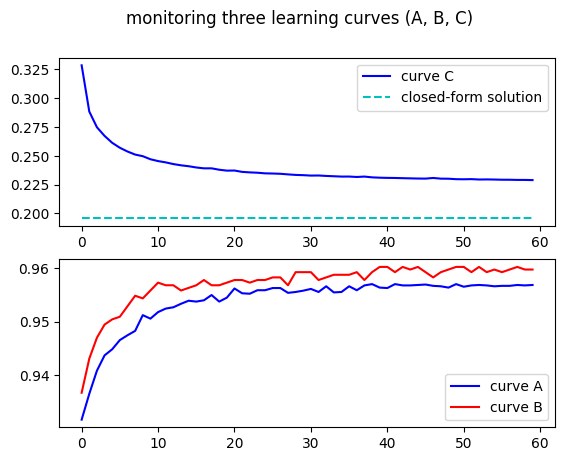

In [ ]:
import matplotlib.pyplot as plt

op = Optimizer(lr=0.003, annealing_rate=0.998, batch_size=64, max_epochs=60)
lmbda = 2

w, A, B, C = ridge_regression_gd(X_train, y_train, X_test, y_test, op, lmbda)

fig, ax = plt.subplots(2)
fig.suptitle('monitoring three learning curves (A, B, C)')
ax[0].plot(C, 'b', 0.196*np.ones(C.shape[0]), 'c--')
ax[0].legend(['curve C', 'closed-form solution'])

ax[1].plot(A, 'b', B, 'r')
ax[1].legend(['curve A', 'curve B'])

After adjusting the hyperparameters (lambda, learning rate, annealing rate, max epochs, etc.), I found this model to have the best results.
This model does not appear to be overfitting, and obtains the highest test accuracy of 96.1%.

Now, we will compare a standard linear regression model to the above derived ridge regression model.

In [ ]:
#Linear Regression Model - Given
# use the closed-form solution

# refer to the closed-form solution, i.e. Eq.(6.9) on page 112
w = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

# calculate the mean square error and classification accuracy on the training set
predict = X_train @ w
error = np.sum((predict - y_train)*(predict - y_train))/X_train.shape[0]
print(f'mean square error on training data for the closed-form solution: {error:.5f}')

accuracy = np.count_nonzero(np.equal(np.sign(predict),y_train))/y_train.size*100.0
print(f'classification accuracy on training data for the closed-form solution: {accuracy:.2f}%')

# calculate the mean square error and classification accuracy on the test set
predict = X_test @ w
error = np.sum((predict - y_test)*(predict - y_test))/X_test.shape[0]
print(f'mean square error on test data for the closed-form solution: {error:.5f}')

accuracy = np.count_nonzero(np.equal(np.sign(predict),y_test))/y_test.size*100.0
print(f'classification accuracy on test data for the closed-form solution: {accuracy:.2f}%')

mean square error on training data for the closed-form solution: 0.20279
classification accuracy on training data for the closed-form solution: 96.50%
mean square error on test data for the closed-form solution: 0.69320
classification accuracy on test data for the closed-form solution: 95.88%


In [ ]:
# solve linear regression using gradient descent
import numpy as np

class Optimizer():
  def __init__(self, lr, annealing_rate, batch_size, max_epochs):
    self.lr = lr
    self.annealing_rate = annealing_rate
    self.batch_size = batch_size
    self.max_epochs = max_epochs

# X[N,d]: training features; y[N]: training targets;
# X2[N,d]: test features; y2[N]: test targets;
# op: hyper-parameters for optimzer
#
# Note: X2 and y2 are not used in training
#       but only for computting the learning curve B
#
def linear_regression_gd2(X, y, X2, y2, op):
  n = X.shape[0]   # number of samples
  w = np.zeros(X.shape[1])  # initialization

  lr = op.lr
  errorsA = np.zeros(op.max_epochs)
  errorsB = np.zeros(op.max_epochs)
  errorsC = np.zeros(op.max_epochs)

  for epoch in range(op.max_epochs):
    indices = np.random.permutation(n)  #randomly shuffle data indices
    for batch_start in range(0, n, op.batch_size):
      X_batch = X[indices[batch_start:batch_start + op.batch_size]]
      y_batch = y[indices[batch_start:batch_start + op.batch_size]]

      # vectorization to compute gradients for a whole mini-batch (see the above formula)
      w_grad = X_batch.T @ X_batch @ w - X_batch.T @ y_batch

      w -= lr * w_grad / X_batch.shape[0]

    # for learning curve C
    diff = X @ w - y  # prediction difference
    errorsC[epoch] = np.sum(diff*diff)/n

    # for learning curve A
    predict = np.sign(X @ w)
    errorsA[epoch] = np.count_nonzero(np.equal(predict,y))/y.size

    # for learning curve B
    predict2 = np.sign(X2 @ w)
    errorsB[epoch] = np.count_nonzero(np.equal(predict2,y2))/y2.size

    lr *= op.annealing_rate
    print(f'epoch={epoch}: the mean square error is {errorsC[epoch]:.3f} ({errorsA[epoch]:.3f},{errorsB[epoch]:.3f})')

  return w, errorsA, errorsB, errorsC

epoch=0: the mean square error is 0.377 (0.928,0.930)
epoch=1: the mean square error is 0.305 (0.933,0.938)
epoch=2: the mean square error is 0.287 (0.938,0.945)
epoch=3: the mean square error is 0.277 (0.939,0.948)
epoch=4: the mean square error is 0.271 (0.942,0.949)
epoch=5: the mean square error is 0.266 (0.944,0.950)
epoch=6: the mean square error is 0.262 (0.945,0.950)
epoch=7: the mean square error is 0.259 (0.947,0.951)
epoch=8: the mean square error is 0.256 (0.947,0.951)
epoch=9: the mean square error is 0.253 (0.948,0.953)
epoch=10: the mean square error is 0.252 (0.947,0.954)
epoch=11: the mean square error is 0.250 (0.950,0.955)
epoch=12: the mean square error is 0.248 (0.950,0.956)
epoch=13: the mean square error is 0.247 (0.951,0.956)
epoch=14: the mean square error is 0.245 (0.951,0.957)
epoch=15: the mean square error is 0.244 (0.952,0.957)
epoch=16: the mean square error is 0.243 (0.952,0.958)
epoch=17: the mean square error is 0.242 (0.952,0.957)
epoch=18: the mean s

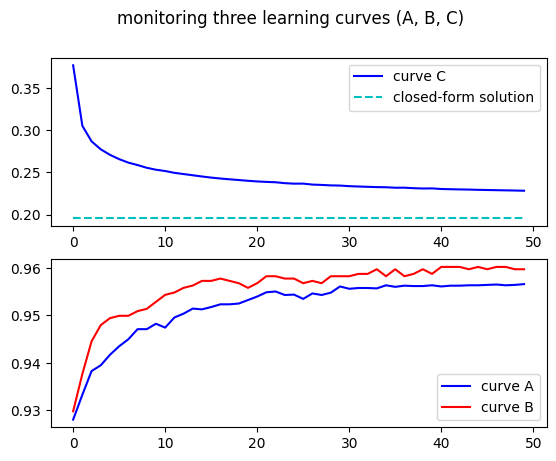

In [ ]:
import matplotlib.pyplot as plt

op = Optimizer(lr=0.002, annealing_rate=0.995, batch_size=64, max_epochs=50)

w, A, B, C = linear_regression_gd2(X_train, y_train, X_test, y_test, op)

fig, ax = plt.subplots(2)
fig.suptitle('monitoring three learning curves (A, B, C)')
ax[0].plot(C, 'b', 0.196*np.ones(C.shape[0]), 'c--')
ax[0].legend(['curve C', 'closed-form solution'])

ax[1].plot(A, 'b', B, 'r')
ax[1].legend(['curve A', 'curve B'])

After testing several sets of hyperparameters, I found this linear regression model to be the best with the highest test accuracy of 96%.

**Overall:**

Above we derived closed form solution models for both the linear and ridge regression models. For the ridge regression model, several values of the regularization parameter were tested including $\lambda=0$. In this case, the ridge model is mathematically equivalent to the linear regression model, thus we notice they both achieve very similar test accuracies (95.93% vs 95.88%). The small difference in test accuracies can be attributed to sampling variability.

Though we notice that once we introduce the lambda parameter, the ridge regression model consistently obtains a higher test accuracy than the standard linear regression model. The best performance was observed when $\lambda = 10$, with a test accuracy of 96.22% and a low test MSE of 0.21539.


While comparing the SGD approaches, both models reach similar peak test accuracies of 96% and 96.1%, respectively. The learning curves for each model exhibit comparable trends, where the training loss
rapidly decreases during initial epochs before gradually flattening out/converging. However, the ridge regression reaches a slightly lower plateau, achieving a minimum mean squared loss of approximately 0.225, compared to 0.24 for the linear regression model. Although neither model attains the ground-truth loss rate of 0.2, the ridge regression model's curve stabilizes more smoothly and at a lower loss value.

**Part 4.2** (10 marks) Implement the SGD for LASSO and compare its solution with that of [the linear regression method](https://colab.research.google.com/drive/1qMWyoqylJpDEbMwtcSGLZJzhJsOyWW8r) in the Boston House data set. Discuss your findings.



In [ ]:
# write your code for Q4.2 here

In the textbook (3.2, p73), Lasso Regression is described as a linear regression model with an additional regularization method, specifically by L1-norm minimization.

From section 7.2, we estimate the Lasso model by minimizing the following objective function:
$$
\mathbf{w^*}_{lasso} = \arg\min_w\left[\frac{1}{2}\sum^N_{i=1}(\mathbf{w}^⊤\mathbf{x}_i - y_i)^2 + \lambda⋅\vert\vert\mathbf{w}\vert\vert_1\right]
$$
No closed form solution exists for this model since this function is not differentiable everywhere.


In matrix form, we can find this to become:

$\frac{1}{2}\sum^N_{i=1}(\mathbf{w}^⊤\mathbf{x}_i - y_i)^2 + \lambda\vert\vert\mathbf{w}\vert\vert_1 = \frac{1}{2}\vert\vert X\mathbf{w} - y\vert\vert^2_2 + \lambda\vert\vert\mathbf{w}\vert\vert_1 $

Then:

$\frac{1}{2}\vert\vert X\mathbf{w} - y\vert\vert^2_2  = \frac{1}{2}(X\mathbf{w} - y)^\top(X\mathbf{w} - y)$

and the gradient becomes:

$X^\top(X\mathbf{w} -y)$

The regularization term, $\lambda\vert\vert\mathbf{w}\vert\vert$, is not differentiable everywhere, and thus, we are unable to take a gradient. Though from pg 140, we can represent the gradient of the function by:

$$
X^\top(X\mathbf{w} -y) + \lambda\cdot\text{sign(}\mathbf{w}\text{)}
$$

In [ ]:
# download boston house data from Google drive

!gdown --folder https://drive.google.com/drive/folders/12L9XNwhIH2wQBa4-IdQrhsrtgRFbeIMZ 2> /dev/null

Processing file 1IZf0tFGW3Zv3Ax5gxKgnklHe1DUI7CAI boston.csv


In [ ]:
# load Boston House data set
import pandas as pd
import numpy as np

raw_data = pd.read_csv('Boston/boston.csv', header=None)
data_rows = np.reshape(raw_data.to_numpy(), (506,14))
data = data_rows[:,:13]
target = data_rows[:,13]

# normalize input features to zero-mean and unit-variance
data = (data-np.mean(data, axis=0))/np.std(data, axis=0)

# add a constant column of '1' to accomodate the bias (see the margin note on page 107)
data_wb = np.hstack((data, np.ones((data.shape[0], 1), dtype=data.dtype)))

print(data_wb.shape)
print(target.shape)

(506, 14)
(506,)


In [ ]:
#USED LINEAR REGRESSION SGD CODE AS TEMPLATE FOR LASSO REGRESSION
import numpy as np

class Optimizer():
  def __init__(self, lr, annealing_rate, batch_size, max_epochs, lambda_reg = 0.1):
    self.lr = lr
    self.annealing_rate = annealing_rate
    self.batch_size = batch_size
    self.max_epochs = max_epochs
    self.lambda_reg=lambda_reg

# X[N,d]: input features; y[N]: output targets; op: hyper-parameters for optimzer
def lasso_regression(X, y, op):
  n = X.shape[0]   # number of samples
  w = np.zeros(X.shape[1])  # initialization

  lr = op.lr
  errors = np.zeros(op.max_epochs)
  for epoch in range(op.max_epochs):
    indices = np.random.permutation(n)  #randomly shuffle data indices
    for batch_start in range(0, n, op.batch_size):
      X_batch = X[indices[batch_start:batch_start + op.batch_size]]
      y_batch = y[indices[batch_start:batch_start + op.batch_size]]

      # computation for the gradient
      w_gradd = X_batch.T @ (X_batch @ w - y_batch) / X_batch.shape[0]
      grad_reg = op.lambda_reg*np.sign(w)
      w_grad = w_gradd + grad_reg

      w -= lr * w_grad

    diff = X @ w - y  # prediction difference
    errors[epoch] = np.sum(diff*diff)/n
    lr *= op.annealing_rate
    print(f'epoch={epoch}: the mean square error is {errors[epoch]}')

  return w, errors

epoch=0: the mean square error is 347.32248395739185
epoch=1: the mean square error is 217.68798404326196
epoch=2: the mean square error is 141.5321024600129
epoch=3: the mean square error is 95.6063083892443
epoch=4: the mean square error is 67.86409146720119
epoch=5: the mean square error is 50.95044573722555
epoch=6: the mean square error is 40.551259987902895
epoch=7: the mean square error is 34.151720743413506
epoch=8: the mean square error is 30.14124956797521
epoch=9: the mean square error is 27.617880097285404
epoch=10: the mean square error is 25.997928789419934
epoch=11: the mean square error is 24.964932538607552
epoch=12: the mean square error is 24.271700045214324
epoch=13: the mean square error is 23.82276487687569
epoch=14: the mean square error is 23.511416929183024
epoch=15: the mean square error is 23.289291653900467
epoch=16: the mean square error is 23.12019007372894
epoch=17: the mean square error is 23.00457148174865
epoch=18: the mean square error is 22.909623626

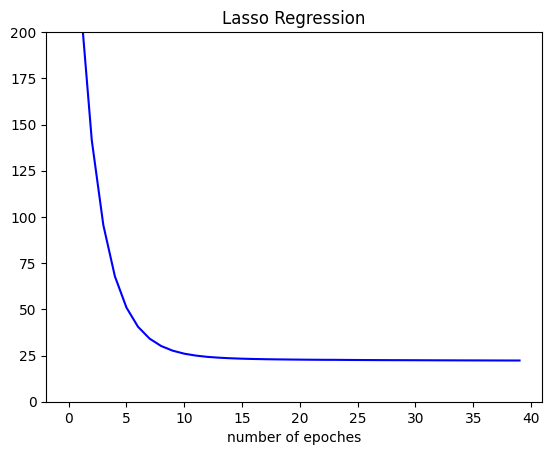

In [ ]:
import matplotlib.pyplot as plt

op = Optimizer(lr=0.001, annealing_rate=0.99, batch_size=2, max_epochs=40,lambda_reg=0.01)

w, errors = lasso_regression(data_wb, target, op)

plt.title('Lasso Regression')
plt.xlabel('number of epoches')
plt.ylim(ymin=0, ymax=200)
plt.plot(errors, 'b', label='Lasso SGD')

In [ ]:
# solve linear regression using gradient descent
import numpy as np

class Optimizer():
  def __init__(self, lr, annealing_rate, batch_size, max_epochs):
    self.lr = lr
    self.annealing_rate = annealing_rate
    self.batch_size = batch_size
    self.max_epochs = max_epochs

# X[N,d]: input features; y[N]: output targets; op: hyper-parameters for optimzer
def linear_regression_gd(X, y, op):
  n = X.shape[0]   # number of samples
  w = np.zeros(X.shape[1])  # initialization

  lr = op.lr
  errors = np.zeros(op.max_epochs)
  for epoch in range(op.max_epochs):
    indices = np.random.permutation(n)  #randomly shuffle data indices
    for batch_start in range(0, n, op.batch_size):
      X_batch = X[indices[batch_start:batch_start + op.batch_size]]
      y_batch = y[indices[batch_start:batch_start + op.batch_size]]

      # vectorization to compute gradients for a whole mini-batch (see the above formula)
      w_grad = X_batch.T @ X_batch @ w - X_batch.T @ y_batch

      w -= lr * w_grad / X_batch.shape[0]

    diff = X @ w - y  # prediction difference
    errors[epoch] = np.sum(diff*diff)/n
    lr *= op.annealing_rate
    print(f'epoch={epoch}: the mean square error is {errors[epoch]}')

  return w, errors

epoch=0: the mean square error is 346.7427341270468
epoch=1: the mean square error is 218.1399111922673
epoch=2: the mean square error is 141.6449438098868
epoch=3: the mean square error is 95.71888975176941
epoch=4: the mean square error is 67.88643789242282
epoch=5: the mean square error is 50.941662713370754
epoch=6: the mean square error is 40.56007118704042
epoch=7: the mean square error is 34.10570556813864
epoch=8: the mean square error is 30.11389000712449
epoch=9: the mean square error is 27.57794353554751
epoch=10: the mean square error is 25.962536224266284
epoch=11: the mean square error is 24.908332427719575
epoch=12: the mean square error is 24.22761151085747
epoch=13: the mean square error is 23.783940579362305
epoch=14: the mean square error is 23.466997206957824
epoch=15: the mean square error is 23.256301643245145
epoch=16: the mean square error is 23.101119769311506
epoch=17: the mean square error is 22.9729757018582
epoch=18: the mean square error is 22.885191380388

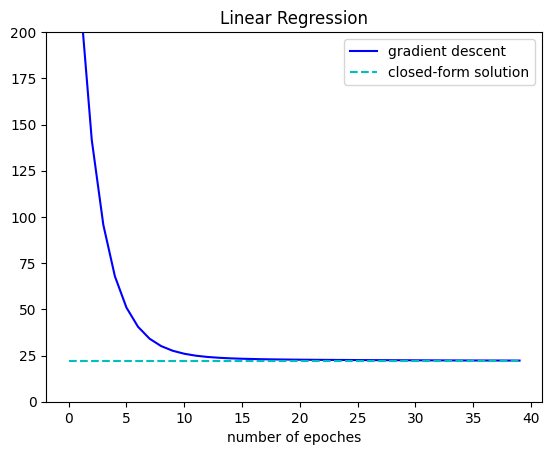

In [ ]:
import matplotlib.pyplot as plt

op = Optimizer(lr=0.001, annealing_rate=0.99, batch_size=2, max_epochs=40)

w, errors = linear_regression_gd(data_wb, target, op)

plt.title('Linear Regression')
plt.xlabel('number of epoches')
plt.plot(errors, 'b', 21.89*np.ones(errors.shape[0]), 'c--')
plt.ylim(ymin=0, ymax=200)
plt.legend(['gradient descent', 'closed-form solution'])

In the plots above, I compared the loss curves for both linear and lasso regression using the Boston Housing dataset. Both models exhibit very similar convergence behaviours, with the loss decreasing rapidly during initial epochs. The linear regression model has a slighly lower loss rate of 22.26, compared to the lasso regression model with 22.30.

These models are very similar which makes sense since the lambda regularization parameter we used is very small - 0.1. This model obtained the best results.